Device: cuda
timm: True, albumentations: True
Config ready. IMG_SIZE: 224, BATCH_SIZE: 32
Albumentations: True
Loading FER CSV: /content/fer2013.csv


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-3439003178.py:69: UserWarning: Argument(s) 'border_value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(


Train: 28709, Val: 7178
Datasets ready. Train: 28709, Val: 7178


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model created. Parameters: 4,051,395

Starting training...
Epoch 1/120 - train_loss: 3.3197, train_acc: 0.1444 | val_loss: 2.0880, val_acc: 0.1826 | lr: 0.000007 (190.4s)
✅ Best model saved: val_acc=0.1826
Epoch 2/120 - train_loss: 2.9137, train_acc: 0.1742 | val_loss: 1.8928, val_acc: 0.2540 | lr: 0.000007 (189.3s)
✅ Best model saved: val_acc=0.2540
Epoch 3/120 - train_loss: 2.6266, train_acc: 0.2029 | val_loss: 1.8053, val_acc: 0.2938 | lr: 0.000010 (189.3s)
✅ Best model saved: val_acc=0.2938
Epoch 4/120 - train_loss: 2.4100, train_acc: 0.2395 | val_loss: 1.6808, val_acc: 0.3649 | lr: 0.000007 (190.1s)
✅ Best model saved: val_acc=0.3649
Epoch 5/120 - train_loss: 2.1849, train_acc: 0.2722 | val_loss: 1.6401, val_acc: 0.3940 | lr: 0.000002 (190.1s)
✅ Best model saved: val_acc=0.3940
Epoch 6/120 - train_loss: 2.1087, train_acc: 0.2851 | val_loss: 1.5910, val_acc: 0.3947 | lr: 0.000010 (190.0s)
✅ Best model saved: val_acc=0.3947
Epoch 7/120 - train_loss: 1.9387, train_acc: 0.3220 | val_l

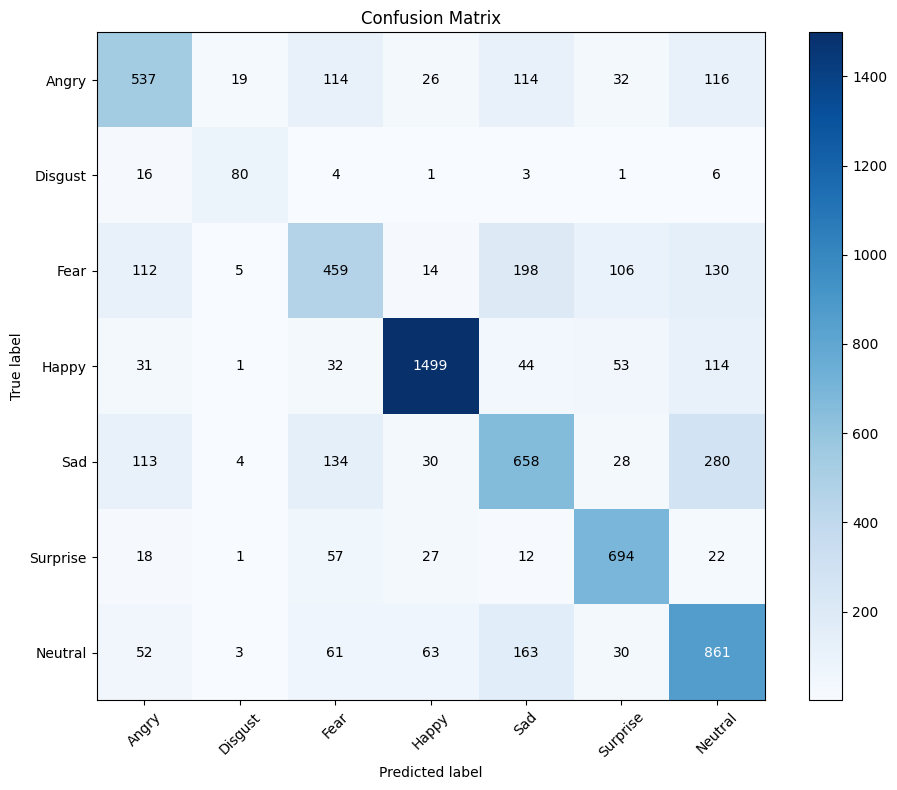


✅ Training complete! Model saved to: /content/output/best_effnet_fer_improved.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==================== CONFIGURATION ====================
import os, sys, math, time, random
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.multiprocessing as mp

try:
    mp.set_start_method('spawn', force=True)
except RuntimeError:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Import libraries
try:
    import timm
    _HAS_TIMM = True
except:
    _HAS_TIMM = False

try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    _HAS_ALB = True
except:
    _HAS_ALB = False

print(f"timm: {_HAS_TIMM}, albumentations: {_HAS_ALB}")

# ==================== CONFIG ====================
DATA_DIR = Path("/content/data")
FER_CSV = Path("/content/fer2013.csv")
OUT_DIR = Path("/content/output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 7
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 120  # Increased with early stopping
LEARNING_RATE = 1e-4  # Reduced initial LR
WEIGHT_DECAY = 1e-3   # Increased weight decay
NUM_WORKERS = 0
PIN_MEMORY = True if device.type == "cuda" else False

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"Config ready. IMG_SIZE: {IMG_SIZE}, BATCH_SIZE: {BATCH_SIZE}")

# ==================== DATA AUGMENTATION ====================
# Enhanced augmentation as per your requirements
if _HAS_ALB:
    train_transform = A.Compose([
        # Geometric augmentations
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.1,      # 10% horizontal/vertical shifting
            scale_limit=0.1,       # 10% zoom
            rotate_limit=10,       # 10 degree rotation
            border_mode=cv2.BORDER_CONSTANT,
            border_value=0, # Changed from 'value' to 'border_value'
            p=0.7
        ),
        A.RandomResizedCrop(
            size=(IMG_SIZE, IMG_SIZE),
            scale=(0.8, 1.0),  # Random crop with 80-100% of original
            p=0.5
        ),

        # Color augmentations (mild to avoid distorting emotion cues)
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.3
        ),

        # Resize to final size
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),

        # Normalize and convert to tensor
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

    val_transform = A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
else:
    from torchvision import transforms
    train_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    ])
    val_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    ])

print("Albumentations:", _HAS_ALB)

# ==================== DATA LOADING ====================
def load_fer_csv(csv_path: Path):
    df = pd.read_csv(csv_path)
    pixels_col = 'pixels' if 'pixels' in df.columns else df.columns[0]
    emotion_col = 'emotion' if 'emotion' in df.columns else df.columns[1]
    usage_col = 'Usage' if 'Usage' in df.columns else None

    records = []
    for _, row in df.iterrows():
        pixels = row[pixels_col]
        if isinstance(pixels, str):
            arr = np.fromstring(pixels, dtype=np.uint8, sep=' ')
        else:
            arr = np.array(pixels, dtype=np.uint8).ravel()
        img = arr.reshape(48, 48).astype(np.uint8)
        records.append({
            'image': img,
            'label': int(row[emotion_col]),
            'Usage': row[usage_col] if usage_col else 'Training'
        })
    return pd.DataFrame(records)

if FER_CSV.exists():
    print(f"Loading FER CSV: {FER_CSV}")
    df_all = load_fer_csv(FER_CSV)
    if 'Usage' in df_all.columns:
        train_df = df_all[df_all['Usage'].str.contains('Training', case=False, na=False)].reset_index(drop=True)
        val_df = df_all[~df_all['Usage'].str.contains('Training', case=False, na=False)].reset_index(drop=True)
    else:
        from sklearn.model_selection import train_test_split
        train_df, val_df = train_test_split(
            df_all, test_size=0.15, random_state=RANDOM_SEED, stratify=df_all['label']
        )
    print(f"Train: {len(train_df)}, Val: {len(val_df)}")
else:
    raise FileNotFoundError(f"CSV not found: {FER_CSV}")

# ==================== DATASET ====================
class FERDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img = row['image']

        # Convert grayscale to RGB
        if img.ndim == 2:
            img_rgb = np.stack([img, img, img], axis=-1)
        else:
            img_rgb = img

        # Resize to target size
        img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)

        label = int(row['label'])

        if _HAS_ALB:
            augmented = self.transform(image=img_rgb)
            tensor = augmented['image']
        else:
            tensor = self.transform(img_rgb)

        return tensor, label

train_dataset = FERDataset(train_df, transform=train_transform)
val_dataset = FERDataset(val_df, transform=val_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

print(f"Datasets ready. Train: {len(train_dataset)}, Val: {len(val_dataset)}")

# ==================== MODEL WITH YOUR ARCHITECTURE ====================
class Swish(nn.Module):
    """Swish activation function: x * sigmoid(x)"""
    def forward(self, x):
        return x * torch.sigmoid(x)

class EmotionEfficientNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        # Load EfficientNet-B0 backbone
        if _HAS_TIMM:
            backbone = timm.create_model('efficientnet_b0', pretrained=True)
            try:
                in_features = backbone.get_classifier().in_features
                backbone.reset_classifier(0)
            except:
                if hasattr(backbone, 'classifier'):
                    in_features = backbone.classifier.in_features
                    backbone.classifier = nn.Identity()
                elif hasattr(backbone, 'fc'):
                    in_features = backbone.fc.in_features
                    backbone.fc = nn.Identity()
            self.backbone = backbone
        else:
            from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
            backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
            in_features = backbone.classifier[1].in_features
            backbone.classifier = nn.Identity()
            self.backbone = backbone

        # Custom head as per your architecture image
        # Layer structure: 1280 -> Flatten -> BatchNorm -> Dropout(0.5) ->
        # Dense(32) -> BatchNorm -> Swish -> Dropout(0.5) -> Dense(8)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(in_features),
            nn.Dropout(0.5),

            nn.Linear(in_features, 32),
            nn.BatchNorm1d(32),
            Swish(),
            nn.Dropout(0.5),

            nn.Linear(32, num_classes)
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        features = self.backbone.forward_features(x) if hasattr(self.backbone, 'forward_features') else self.backbone(x)
        if features.dim() == 4:
            features = nn.functional.adaptive_avg_pool2d(features, 1).reshape(features.size(0), -1)
        out = self.head(features)
        return out

model = EmotionEfficientNet(num_classes=NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model created. Parameters: {total_params:,}")

# ==================== TRAINING SETUP ====================
# Calculate class weights for imbalanced dataset
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer with different learning rates for backbone and head
backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if 'backbone' in name:
        backbone_params.append(param)
    else:
        head_params.append(param)

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LEARNING_RATE * 0.1},  # Lower LR for pretrained backbone
    {'params': head_params, 'lr': LEARNING_RATE}
], weight_decay=WEIGHT_DECAY)

# Cosine annealing with warm restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

# Early stopping
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

early_stopping = EarlyStopping(patience=7, min_delta=0.001)

# ==================== TRAINING FUNCTIONS ====================
from sklearn.metrics import accuracy_score

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

        _, preds = torch.max(outputs, dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(yb.detach().cpu().numpy())

        scheduler.step()

    epoch_loss = running_loss / len(loader.dataset)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_loss += loss.item() * xb.size(0)

            _, preds = torch.max(outputs, dim=1)
            all_preds.append(preds.detach().cpu().numpy())
            all_labels.append(yb.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

# ==================== TRAINING LOOP ====================
best_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
save_path = OUT_DIR / "best_effnet_fer_improved.pth"

print("\nStarting training...")
for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0

    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} | "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f} | "
          f"lr: {current_lr:.6f} ({elapsed:.1f}s)")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, str(save_path))
        print(f"✅ Best model saved: val_acc={val_acc:.4f}")

    # Early stopping check
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
        break

print(f"\nTraining complete - Best val acc: {best_acc:.4f}")

# ==================== EVALUATION ====================
try:
    from sklearn.metrics import confusion_matrix, classification_report

    checkpoint = torch.load(save_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device).eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            out = model(xb)
            _, preds = out.max(1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(yb.numpy())

    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=['Angry', 'Disgust', 'Fear', 'Happy',
                                            'Sad', 'Surprise', 'Neutral']))

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(NUM_CLASSES)
    emotions = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
    plt.xticks(tick_marks, emotions, rotation=45)
    plt.yticks(tick_marks, emotions)

    # Add text annotations
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Evaluation error: {e}")

print("\n✅ Training complete! Model saved to:", save_path)
# ==================== DOWNLOAD TRAINED MODEL ====================
from google.colab import files

download_path = "/content/output/best_effnet_fer_improved.pth"
files.download(download_path)



In [1]:
log_text = """
Epoch 1/120 - train_loss: 3.3197, train_acc: 0.1444 | val_loss: 2.0880, val_acc: 0.1826 | lr: 0.000007 (190.4s)
✅ Best model saved: val_acc=0.1826
Epoch 2/120 - train_loss: 2.9137, train_acc: 0.1742 | val_loss: 1.8928, val_acc: 0.2540 | lr: 0.000007 (189.3s)
✅ Best model saved: val_acc=0.2540
Epoch 3/120 - train_loss: 2.6266, train_acc: 0.2029 | val_loss: 1.8053, val_acc: 0.2938 | lr: 0.000010 (189.3s)
✅ Best model saved: val_acc=0.2938
Epoch 4/120 - train_loss: 2.4100, train_acc: 0.2395 | val_loss: 1.6808, val_acc: 0.3649 | lr: 0.000007 (190.1s)
✅ Best model saved: val_acc=0.3649
Epoch 5/120 - train_loss: 2.1849, train_acc: 0.2722 | val_loss: 1.6401, val_acc: 0.3940 | lr: 0.000002 (190.1s)
✅ Best model saved: val_acc=0.3940
Epoch 6/120 - train_loss: 2.1087, train_acc: 0.2851 | val_loss: 1.5910, val_acc: 0.3947 | lr: 0.000010 (190.0s)
✅ Best model saved: val_acc=0.3947
Epoch 7/120 - train_loss: 1.9387, train_acc: 0.3220 | val_loss: 1.4980, val_acc: 0.4494 | lr: 0.000009 (189.6s)
✅ Best model saved: val_acc=0.4494
Epoch 8/120 - train_loss: 1.7894, train_acc: 0.3548 | val_loss: 1.4457, val_acc: 0.4689 | lr: 0.000007 (190.3s)
✅ Best model saved: val_acc=0.4689
Epoch 9/120 - train_loss: 1.6982, train_acc: 0.3837 | val_loss: 1.4082, val_acc: 0.4808 | lr: 0.000004 (189.5s)
✅ Best model saved: val_acc=0.4808
Epoch 10/120 - train_loss: 1.6530, train_acc: 0.4029 | val_loss: 1.3924, val_acc: 0.4870 | lr: 0.000002 (189.7s)
✅ Best model saved: val_acc=0.4870
Epoch 11/120 - train_loss: 1.6300, train_acc: 0.4087 | val_loss: 1.3817, val_acc: 0.4919 | lr: 0.000001 (189.5s)
✅ Best model saved: val_acc=0.4919
Epoch 12/120 - train_loss: 1.6165, train_acc: 0.4154 | val_loss: 1.3554, val_acc: 0.5068 | lr: 0.000010 (189.5s)
✅ Best model saved: val_acc=0.5068
Epoch 13/120 - train_loss: 1.5284, train_acc: 0.4426 | val_loss: 1.3009, val_acc: 0.5308 | lr: 0.000010 (188.8s)
✅ Best model saved: val_acc=0.5308
Epoch 14/120 - train_loss: 1.4708, train_acc: 0.4678 | val_loss: 1.2633, val_acc: 0.5354 | lr: 0.000009 (189.0s)
✅ Best model saved: val_acc=0.5354
Epoch 15/120 - train_loss: 1.4213, train_acc: 0.4895 | val_loss: 1.2271, val_acc: 0.5518 | lr: 0.000008 (189.1s)
✅ Best model saved: val_acc=0.5518
Epoch 16/120 - train_loss: 1.3844, train_acc: 0.4983 | val_loss: 1.2067, val_acc: 0.5560 | lr: 0.000007 (189.6s)
✅ Best model saved: val_acc=0.5560
Epoch 17/120 - train_loss: 1.3575, train_acc: 0.5146 | val_loss: 1.1951, val_acc: 0.5617 | lr: 0.000006 (189.6s)
✅ Best model saved: val_acc=0.5617
Epoch 18/120 - train_loss: 1.3331, train_acc: 0.5185 | val_loss: 1.1637, val_acc: 0.5681 | lr: 0.000004 (189.1s)
✅ Best model saved: val_acc=0.5681
Epoch 19/120 - train_loss: 1.3032, train_acc: 0.5306 | val_loss: 1.1594, val_acc: 0.5807 | lr: 0.000003 (189.5s)
✅ Best model saved: val_acc=0.5807
Epoch 20/120 - train_loss: 1.3033, train_acc: 0.5344 | val_loss: 1.1511, val_acc: 0.5765 | lr: 0.000002 (189.6s)
Epoch 21/120 - train_loss: 1.2897, train_acc: 0.5336 | val_loss: 1.1470, val_acc: 0.5858 | lr: 0.000002 (189.6s)
✅ Best model saved: val_acc=0.5858
Epoch 22/120 - train_loss: 1.2902, train_acc: 0.5335 | val_loss: 1.1436, val_acc: 0.5791 | lr: 0.000001 (190.2s)
Epoch 23/120 - train_loss: 1.2742, train_acc: 0.5400 | val_loss: 1.1443, val_acc: 0.5793 | lr: 0.000010 (189.3s)
Epoch 24/120 - train_loss: 1.2559, train_acc: 0.5490 | val_loss: 1.1212, val_acc: 0.5837 | lr: 0.000010 (189.0s)
Epoch 25/120 - train_loss: 1.2370, train_acc: 0.5574 | val_loss: 1.0951, val_acc: 0.5952 | lr: 0.000010 (189.3s)
✅ Best model saved: val_acc=0.5952
Epoch 26/120 - train_loss: 1.1958, train_acc: 0.5675 | val_loss: 1.0789, val_acc: 0.6049 | lr: 0.000010 (188.9s)
✅ Best model saved: val_acc=0.6049
Epoch 27/120 - train_loss: 1.1634, train_acc: 0.5786 | val_loss: 1.0604, val_acc: 0.6106 | lr: 0.000009 (188.8s)
✅ Best model saved: val_acc=0.6106
Epoch 28/120 - train_loss: 1.1461, train_acc: 0.5867 | val_loss: 1.0504, val_acc: 0.6163 | lr: 0.000009 (189.2s)
✅ Best model saved: val_acc=0.6163
Epoch 29/120 - train_loss: 1.1121, train_acc: 0.5941 | val_loss: 1.0617, val_acc: 0.6232 | lr: 0.000008 (189.6s)
✅ Best model saved: val_acc=0.6232
Epoch 30/120 - train_loss: 1.0945, train_acc: 0.6039 | val_loss: 1.0289, val_acc: 0.6229 | lr: 0.000008 (189.9s)
Epoch 31/120 - train_loss: 1.0835, train_acc: 0.6051 | val_loss: 1.0266, val_acc: 0.6296 | lr: 0.000007 (189.9s)
✅ Best model saved: val_acc=0.6296
Epoch 32/120 - train_loss: 1.0703, train_acc: 0.6131 | val_loss: 1.0155, val_acc: 0.6268 | lr: 0.000007 (189.8s)
Epoch 33/120 - train_loss: 1.0465, train_acc: 0.6203 | val_loss: 1.0135, val_acc: 0.6280 | lr: 0.000006 (190.1s)
Epoch 34/120 - train_loss: 1.0348, train_acc: 0.6226 | val_loss: 1.0040, val_acc: 0.6308 | lr: 0.000006 (189.9s)
✅ Best model saved: val_acc=0.6308
Epoch 35/120 - train_loss: 1.0153, train_acc: 0.6305 | val_loss: 1.0066, val_acc: 0.6308 | lr: 0.000005 (189.7s)
Epoch 36/120 - train_loss: 1.0033, train_acc: 0.6339 | val_loss: 0.9953, val_acc: 0.6375 | lr: 0.000004 (189.7s)
✅ Best model saved: val_acc=0.6375
Epoch 37/120 - train_loss: 0.9924, train_acc: 0.6339 | val_loss: 0.9950, val_acc: 0.6365 | lr: 0.000004 (189.8s)
Epoch 38/120 - train_loss: 0.9891, train_acc: 0.6371 | val_loss: 0.9907, val_acc: 0.6422 | lr: 0.000003 (189.7s)
✅ Best model saved: val_acc=0.6422
Epoch 39/120 - train_loss: 0.9802, train_acc: 0.6403 | val_loss: 0.9961, val_acc: 0.6400 | lr: 0.000003 (189.9s)
Epoch 40/120 - train_loss: 0.9764, train_acc: 0.6420 | val_loss: 0.9914, val_acc: 0.6390 | lr: 0.000002 (190.0s)
Epoch 41/120 - train_loss: 0.9833, train_acc: 0.6435 | val_loss: 0.9864, val_acc: 0.6414 | lr: 0.000002 (189.9s)
Epoch 42/120 - train_loss: 0.9697, train_acc: 0.6460 | val_loss: 1.0004, val_acc: 0.6450 | lr: 0.000002 (189.9s)
✅ Best model saved: val_acc=0.6450
Epoch 43/120 - train_loss: 0.9721, train_acc: 0.6396 | val_loss: 0.9973, val_acc: 0.6470 | lr: 0.000001 (189.9s)
✅ Best model saved: val_acc=0.6470
Epoch 44/120 - train_loss: 0.9642, train_acc: 0.6465 | val_loss: 0.9859, val_acc: 0.6447 | lr: 0.000001 (190.2s)
Epoch 45/120 - train_loss: 0.9623, train_acc: 0.6508 | val_loss: 0.9998, val_acc: 0.6427 | lr: 0.000001 (190.0s)
Epoch 46/120 - train_loss: 0.9628, train_acc: 0.6452 | val_loss: 0.9886, val_acc: 0.6449 | lr: 0.000010 (189.7s)
Epoch 47/120 - train_loss: 0.9592, train_acc: 0.6494 | val_loss: 0.9775, val_acc: 0.6454 | lr: 0.000010 (189.5s)
Epoch 48/120 - train_loss: 0.9430, train_acc: 0.6538 | val_loss: 0.9835, val_acc: 0.6512 | lr: 0.000010 (189.6s)
✅ Best model saved: val_acc=0.6512
Epoch 49/120 - train_loss: 0.9218, train_acc: 0.6601 | val_loss: 0.9862, val_acc: 0.6467 | lr: 0.000010 (190.8s)
Epoch 50/120 - train_loss: 0.9007, train_acc: 0.6669 | val_loss: 0.9780, val_acc: 0.6556 | lr: 0.000010 (191.2s)
✅ Best model saved: val_acc=0.6556
Epoch 51/120 - train_loss: 0.8954, train_acc: 0.6723 | val_loss: 0.9652, val_acc: 0.6552 | lr: 0.000010 (191.6s)
Epoch 52/120 - train_loss: 0.8768, train_acc: 0.6734 | val_loss: 0.9776, val_acc: 0.6599 | lr: 0.000010 (190.7s)
✅ Best model saved: val_acc=0.6599
Epoch 53/120 - train_loss: 0.8595, train_acc: 0.6834 | val_loss: 0.9767, val_acc: 0.6584 | lr: 0.000009 (192.5s)
Epoch 54/120 - train_loss: 0.8407, train_acc: 0.6883 | val_loss: 0.9746, val_acc: 0.6651 | lr: 0.000009 (191.7s)
✅ Best model saved: val_acc=0.6651
Epoch 55/120 - train_loss: 0.8348, train_acc: 0.6853 | val_loss: 0.9696, val_acc: 0.6644 | lr: 0.000009 (190.9s)
Epoch 56/120 - train_loss: 0.8146, train_acc: 0.6958 | val_loss: 0.9860, val_acc: 0.6606 | lr: 0.000009 (191.4s)
Epoch 57/120 - train_loss: 0.8005, train_acc: 0.7000 | val_loss: 0.9864, val_acc: 0.6670 | lr: 0.000009 (191.2s)
✅ Best model saved: val_acc=0.6670
Epoch 58/120 - train_loss: 0.7940, train_acc: 0.7057 | val_loss: 0.9813, val_acc: 0.6649 | lr: 0.000008 (190.8s)

⚠️ Early stopping triggered at epoch 58

Training complete - Best val acc: 0.6670
"""


In [2]:
import re

train_acc = []
val_acc = []

for line in log_text.split("\n"):
    t = re.search(r"train_acc:\s([\d.]+)", line)
    v = re.search(r"val_acc:\s([\d.]+)", line)
    if t and v:
        train_acc.append(float(t.group(1)))
        val_acc.append(float(v.group(1)))


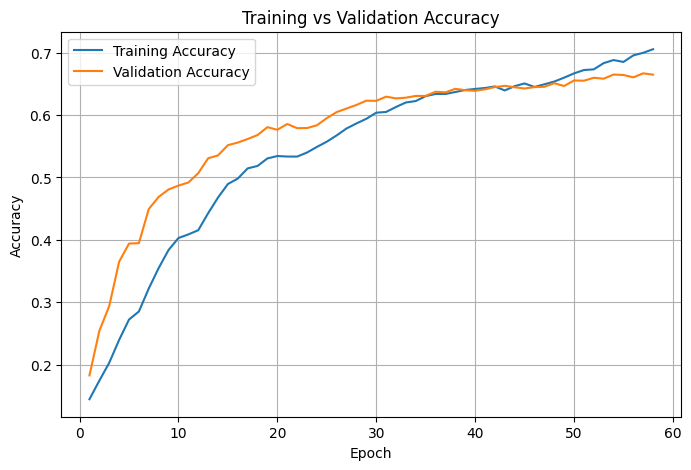

In [3]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
import re

train_loss = []
val_loss = []

for line in log_text.split("\n"):
    t = re.search(r"train_loss:\s([\d.]+)", line)
    v = re.search(r"val_loss:\s([\d.]+)", line)
    if t and v:
        train_loss.append(float(t.group(1)))
        val_loss.append(float(v.group(1)))


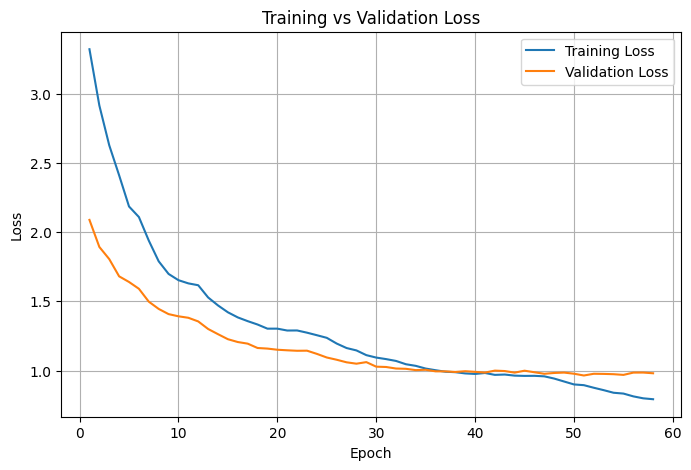

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


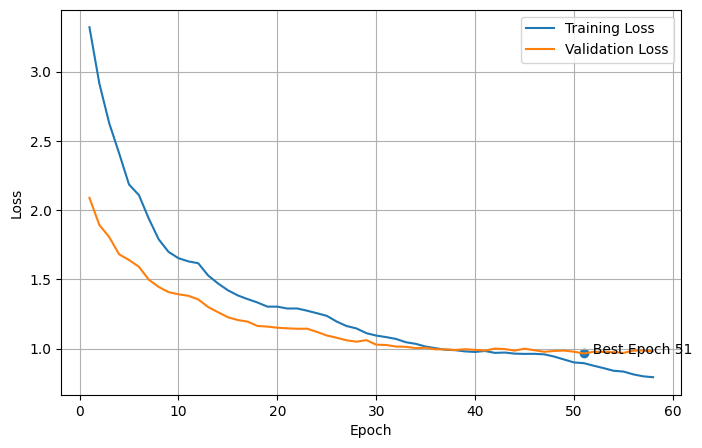

In [6]:
best_epoch = val_loss.index(min(val_loss)) + 1
best_val = min(val_loss)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.scatter(best_epoch, best_val)
plt.text(best_epoch, best_val, f"  Best Epoch {best_epoch}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
